In [1]:
# ── Cell 0.1: Imports ─────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

In [2]:
# ── Cell 0.2: Style & Paths ───────────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 11
plt.rcParams['axes.titlesize'] = 13

cwd = os.getcwd()
if os.path.basename(cwd) == 'notebooks':
    FIGURES_PATH   = os.path.join("..", "outputs", "figures")
    PROCESSED_PATH = os.path.join("..", "data", "processed")
    ENV_PATH       = "../.env"
else:
    FIGURES_PATH   = os.path.join("outputs", "figures")
    PROCESSED_PATH = os.path.join("data", "processed")
    ENV_PATH       = ".env"

os.makedirs(FIGURES_PATH,   exist_ok=True)
os.makedirs(PROCESSED_PATH, exist_ok=True)

print(f"✓ Figures  → {os.path.abspath(FIGURES_PATH)}")
print(f"✓ Outputs  → {os.path.abspath(PROCESSED_PATH)}")

✓ Figures  → C:\Users\jabez\Documents\ai-job-displacement-observatory\outputs\figures
✓ Outputs  → C:\Users\jabez\Documents\ai-job-displacement-observatory\data\processed


In [3]:
# ── Cell 0.3: Database Connection ────────────────────────────────────────────
load_dotenv(ENV_PATH)

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

with engine.connect() as conn:
    count = conn.execute(text("SELECT COUNT(*) FROM bls_oews")).scalar()
print(f"✓ Connected. bls_oews: {count:,} rows")

✓ Connected. bls_oews: 1,182,597 rows


In [4]:
# ── Cell 0.4: Constants ───────────────────────────────────────────────────────
DETAILED_FILTER = "RIGHT(occ_code, 1) != '0'"
MAJOR_FILTER    = "RIGHT(occ_code, 4) = '0000' AND occ_code != '00-0000'"

HIGH_AI_ACTIVITIES = [
    "Processing Information",
    "Analyzing Data or Information",
    "Documenting/Recording Information",
    "Interacting With Computers",
]

WEIGHTS = {
    'automation_prob':      0.40,
    'ai_exposure_score':    0.25,
    'emp_trend_risk':       0.20,
    'wage_stagnation_risk': 0.15,
}

CPI_CAGR     = 0.035   # approx. annualized U.S. CPI growth 2018-2025
NEUTRAL_FILL = 0.5     # fallback for missing features

print(f"✓ Weights sum to: {sum(WEIGHTS.values()):.2f}  (must equal 1.00)")

✓ Weights sum to: 1.00  (must equal 1.00)


## Section 1 — Occupation Master Table

Before building features, establish the full set of occupations we're scoring.
This acts as the "spine" — every feature table will left-join onto it,
ensuring no occupation is silently dropped due to missing data in one source.

In [5]:
# ── Cell 1.1: Occupation Master Table ────────────────────────────────────────
# All unique BLS 2025 national detailed occupations — this is what we're scoring.
df_master = pd.read_sql(f"""
    SELECT DISTINCT occ_code, occ_title
    FROM bls_oews
    WHERE year = 2025
      AND data_type = 'national'
      AND {DETAILED_FILTER}
""", engine)

df_master['major_code'] = df_master['occ_code'].str[:2]

print(f"Occupation master table: {len(df_master):,} unique occupations")
print(f"Major groups represented: {df_master['major_code'].nunique()}")
print(df_master.head(5).to_string(index=False))

Occupation master table: 823 unique occupations
Major groups represented: 22
occ_code                           occ_title major_code
 11-1011                    Chief Executives         11
 11-1021     General and Operations Managers         11
 11-2011 Advertising and Promotions Managers         11
 11-2021                  Marketing Managers         11
 11-2022                      Sales Managers         11


## Section 2 — Feature 1: Automation Probability

Source: Frey & Osborne (2013)  |  Weight: 40%

This is the most important single feature — it captures the intrinsic structure
of each job: how much of it consists of tasks that follow explicit rules, operate
on structured data, or require predictable physical actions.

**Imputation strategy for unmatched occupations (~15–20%):**
New SOC codes created after 2013 have no score. Rather than dropping them,
I assign the median automation probability of all *matched* occupations in the
same 2-digit major group. Example: "Data Scientists" (15-2051) gets the median
of all matched Computer and Mathematical occupations.

In [6]:
# ── Cell 2.1: Load & Join Automation Scores ───────────────────────────────────
df_auto_raw = pd.read_sql(
    "SELECT occ_code, automation_prob, education_req FROM automation_scores",
    engine
)

df_feat = df_master.merge(df_auto_raw, on='occ_code', how='left')
df_feat['score_source'] = np.where(df_feat['automation_prob'].isna(), 'imputed', 'actual')

actual_n  = (df_feat['score_source'] == 'actual').sum()
imputed_n = (df_feat['score_source'] == 'imputed').sum()

print(f"Occupations with actual score:  {actual_n:,}  ({actual_n/len(df_feat)*100:.1f}%)")
print(f"Occupations needing imputation: {imputed_n:,}  ({imputed_n/len(df_feat)*100:.1f}%)")

print(f"\nTop 5 major groups with most unmatched occupations:")
unmatched_by_group = (
    df_feat[df_feat['score_source'] == 'imputed']
    .groupby('major_code')
    .size()
    .sort_values(ascending=False)
    .head(5)
)
print(unmatched_by_group.to_string())

Occupations with actual score:  605  (73.5%)
Occupations needing imputation: 218  (26.5%)

Top 5 major groups with most unmatched occupations:
major_code
25    49
29    40
15    17
53    13
51    11


In [7]:
# ── Cell 2.2: Impute Missing Automation Scores ────────────────────────────────
# Compute median automation_prob per major group using only ACTUAL scores.
# For any group with no actual scores at all, fall back to the dataset median.

major_medians  = (
    df_feat[df_feat['score_source'] == 'actual']
    .groupby('major_code')['automation_prob']
    .median()
    .to_dict()
)
overall_median = df_feat['automation_prob'].median()

print(f"Overall median automation probability: {overall_median:.3f}")
print(f"\nImputed median by major group:")
for code, median in sorted(major_medians.items()):
    print(f"  {code}: {median:.3f}")

Overall median automation probability: 0.650

Imputed median by major group:
  11: 0.030
  13: 0.570
  15: 0.129
  17: 0.120
  19: 0.061
  21: 0.014
  23: 0.410
  25: 0.130
  27: 0.065
  29: 0.034
  31: 0.540
  33: 0.340
  35: 0.845
  37: 0.730
  39: 0.540
  41: 0.855
  43: 0.945
  45: 0.830
  47: 0.820
  49: 0.715
  51: 0.880
  53: 0.830


In [8]:
def impute_automation(row):
    if pd.isna(row['automation_prob']):
        return major_medians.get(row['major_code'], overall_median)
    return row['automation_prob']

df_feat['automation_prob'] = df_feat.apply(impute_automation, axis=1)

print(f"✓ Imputation complete. Null values remaining: {df_feat['automation_prob'].isna().sum()}")
print(f"\nAutomation probability summary:")
print(df_feat['automation_prob'].describe().apply(lambda x: f"{x:.4f}"))

✓ Imputation complete. Null values remaining: 0

Automation probability summary:
count    823.0000
mean       0.4795
std        0.3739
min        0.0028
25%        0.0725
50%        0.5400
75%        0.8500
max        0.9900
Name: automation_prob, dtype: str


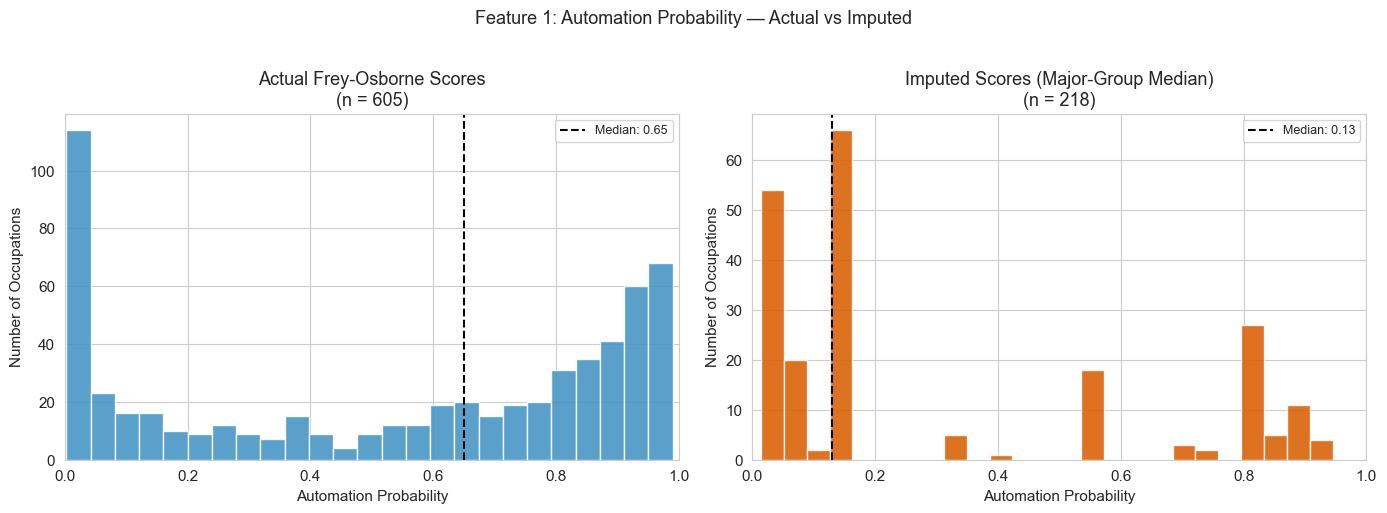

✓ Saved: p5_01_automation_actual_vs_imputed.png


In [9]:
# ── Cell 2.3: Chart — Actual vs Imputed Automation Score Distribution ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, source, color, title in zip(
    axes,
    ['actual', 'imputed'],
    ['#4393c3', '#d95f02'],
    ['Actual Frey-Osborne Scores', 'Imputed Scores (Major-Group Median)']
):
    data = df_feat[df_feat['score_source'] == source]['automation_prob']
    ax.hist(data, bins=25, color=color, edgecolor='white', alpha=0.88)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.2f}')
    ax.set_xlabel("Automation Probability")
    ax.set_ylabel("Number of Occupations")
    ax.set_title(f"{title}\n(n = {len(data):,})")
    ax.set_xlim(0, 1)
    ax.legend(fontsize=9)

fig.suptitle("Feature 1: Automation Probability — Actual vs Imputed",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/p5_01_automation_actual_vs_imputed.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: p5_01_automation_actual_vs_imputed.png")

## Section 3 — Feature 2: Employment Trend Risk

Source: BLS OEWS 2018 & 2025 (national)  |  Weight: 20%

A job that is structurally declining carries higher displacement risk —
it's losing workers even before AI becomes the direct cause.
We measure this as the Compound Annual Growth Rate (CAGR) from 2018 to 2025.

**CAGR formula:**  `(employment_2025 / employment_2018)^(1/7) - 1`

The 7 in the exponent = 7 years between 2018 and 2025. This annualizes the
total change so a 7-year +21% growth = same CAGR as a 1-year +3% growth.

I excluded 2020 from the endpoints to avoid COVID distortion — I'm measuring
structural trends, not pandemic shocks. Using 2018 and 2025 as the
start/end gives a clean 7-year window spanning both endpoints of the data.

CAGR is converted to a 0-1 risk score via **percentile rank** (inverted):
the occupation with the steepest employment decline ranks at risk ≈ 1.0,
the fastest-growing occupation ranks at risk ≈ 0.0.

In [10]:
# ── Cell 3.1: Load Employment for 2018 & 2025 ────────────────────────────────
df_emp = pd.read_sql(f"""
    SELECT year, occ_code, tot_emp
    FROM bls_oews
    WHERE data_type = 'national'
      AND {DETAILED_FILTER}
      AND year IN (2018, 2025)
      AND tot_emp IS NOT NULL
""", engine)

df_emp['tot_emp'] = pd.to_numeric(df_emp['tot_emp'], errors='coerce')
df_emp = df_emp.dropna(subset=['tot_emp'])

df_2018 = (df_emp[df_emp['year'] == 2018][['occ_code', 'tot_emp']]
           .rename(columns={'tot_emp': 'emp_2018'}))
df_2025 = (df_emp[df_emp['year'] == 2025][['occ_code', 'tot_emp']]
           .rename(columns={'tot_emp': 'emp_2025'}))

df_trend = df_2018.merge(df_2025, on='occ_code', how='inner')
df_trend = df_trend[(df_trend['emp_2018'] > 0) & (df_trend['emp_2025'] >= 0)]

print(f"Occupations with both 2018 and 2025 data: {len(df_trend):,}")
print(f"Master table occupations: {len(df_master):,}")
print(f"Coverage: {len(df_trend)/len(df_master)*100:.1f}%")

Occupations with both 2018 and 2025 data: 718
Master table occupations: 823
Coverage: 87.2%


In [11]:
# ── Cell 3.2: Compute CAGR 2018-2025 ─────────────────────────────────────────
df_trend['emp_cagr'] = (df_trend['emp_2025'] / df_trend['emp_2018']) ** (1 / 7) - 1

print(f"Employment CAGR summary (2018-2025):")
print(df_trend['emp_cagr'].describe().apply(lambda x: f"{x:.2%}"))

print(f"\nTop 5 fastest-growing occupations:")
print(df_trend.nlargest(5, 'emp_cagr')[['occ_code', 'emp_cagr']].to_string(index=False))

print(f"\nTop 5 fastest-declining occupations:")
print(df_trend.nsmallest(5, 'emp_cagr')[['occ_code', 'emp_cagr']].to_string(index=False))

Employment CAGR summary (2018-2025):
count    71800.00%
mean        -0.43%
std          4.23%
min        -17.36%
25%         -2.64%
50%         -0.11%
75%          1.99%
max         19.61%
Name: emp_cagr, dtype: str

Top 5 fastest-growing occupations:
occ_code  emp_cagr
 47-2231  0.196117
 35-2013  0.132637
 29-1024  0.125617
 29-2053  0.119193
 29-1129  0.095580

Top 5 fastest-declining occupations:
occ_code  emp_cagr
 33-1099 -0.173613
 51-9151 -0.163009
 41-9091 -0.160982
 39-3021 -0.155717
 43-9031 -0.153318


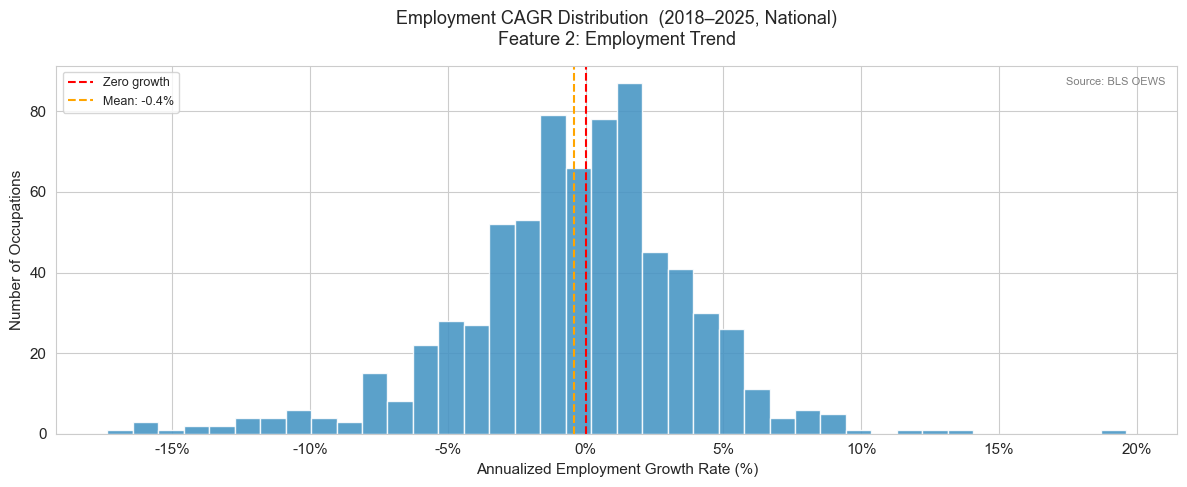

✓ Saved: p5_02_employment_cagr_distribution.png


In [12]:
# ── Cell 3.3: Chart — Employment CAGR Distribution ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df_trend['emp_cagr'] * 100, bins=40, color='#4393c3', edgecolor='white', alpha=0.87)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero growth')
ax.axvline(df_trend['emp_cagr'].mean() * 100, color='orange', linestyle='--',
           linewidth=1.5, label=f"Mean: {df_trend['emp_cagr'].mean():.1%}")

ax.set_xlabel("Annualized Employment Growth Rate (%)")
ax.set_ylabel("Number of Occupations")
ax.set_title("Employment CAGR Distribution  (2018–2025, National)\nFeature 2: Employment Trend", pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.legend(fontsize=9)
ax.text(0.99, 0.97, "Source: BLS OEWS",
        transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/p5_02_employment_cagr_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: p5_02_employment_cagr_distribution.png")

In [13]:
# ── Cell 3.4: Convert CAGR to 0-1 Risk Score ─────────────────────────────────
# rank(pct=True) assigns 0 to the smallest CAGR (fastest decline)
# and 1 to the largest CAGR (fastest growth).
# Inverting it: fastest decline → emp_trend_risk = 1.0 (highest risk)

df_trend['emp_trend_risk'] = 1 - df_trend['emp_cagr'].rank(pct=True)

print("Employment trend risk score summary:")
print(df_trend['emp_trend_risk'].describe().apply(lambda x: f"{x:.4f}"))

Employment trend risk score summary:
count    718.0000
mean       0.4993
std        0.2889
min        0.0000
25%        0.2497
50%        0.4993
75%        0.7490
max        0.9986
Name: emp_trend_risk, dtype: str


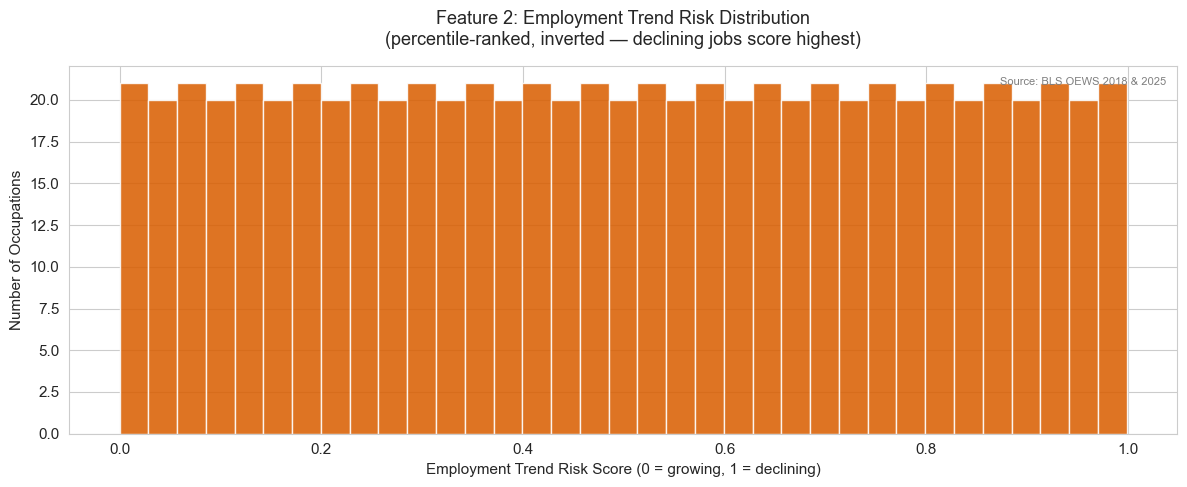

✓ Saved: p5_03_employment_trend_risk.png


In [14]:
# ── Cell 3.5: Chart — Employment Trend Risk Distribution ─────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df_trend['emp_trend_risk'], bins=35, color='#d95f02', edgecolor='white', alpha=0.87)
ax.set_xlabel("Employment Trend Risk Score (0 = growing, 1 = declining)")
ax.set_ylabel("Number of Occupations")
ax.set_title("Feature 2: Employment Trend Risk Distribution\n"
             "(percentile-ranked, inverted — declining jobs score highest)", pad=15)
ax.text(0.99, 0.97, "Source: BLS OEWS 2018 & 2025",
        transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/p5_03_employment_trend_risk.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: p5_03_employment_trend_risk.png")

## Section 4 — Feature 3: O*NET AI Exposure Score

Source: O*NET Work Activities, Importance (IM) scale  |  Weight: 25%

This feature adds a dimension Frey-Osborne alone can't capture: *what kind of
cognitive work* does the occupation perform? A job might score 0.65 on
automation probability (medium risk), but if 80% of the work is analyzing data,
it's far more exposed to LLM-based tools than that score suggests.

I average the Importance score across four activities shown in the EDA heatmap
to most differentiate high-risk from low-risk occupations.

**Normalization:** IM scores range 1–5. We map to 0–1 with: `(score - 1) / 4`

In [15]:
# ── Cell 4.1: Load O*NET High-AI-Exposure Activities ─────────────────────────
activity_sql = ", ".join([f"'{a}'" for a in HIGH_AI_ACTIVITIES])

df_onet_ai = pd.read_sql(f"""
    SELECT onet_soc_code, element_name, data_value
    FROM onet_work_activities
    WHERE scale_id    = 'IM'
      AND element_name IN ({activity_sql})
      AND data_value IS NOT NULL
""", engine)

print(f"Rows loaded: {len(df_onet_ai):,}")
print(f"Activities present: {df_onet_ai['element_name'].unique().tolist()}")
print(f"Occupations covered: {df_onet_ai['onet_soc_code'].nunique():,}")

Rows loaded: 2,682
Activities present: ['Processing Information', 'Analyzing Data or Information', 'Documenting/Recording Information']
Occupations covered: 894


In [16]:
# ── Cell 4.2: Average and Normalize to 0-1 ───────────────────────────────────
df_ai = (
    df_onet_ai
    .groupby('onet_soc_code')['data_value']
    .mean()
    .reset_index()
    .rename(columns={'data_value': 'ai_exposure_raw'})
)

# Normalize: (score - 1) / 4 maps the 1-5 IM scale to 0-1
df_ai['ai_exposure_score'] = (df_ai['ai_exposure_raw'] - 1) / 4

# Strip O*NET's ".00" suffix to get the 7-char BLS SOC code
df_ai['occ_code'] = df_ai['onet_soc_code'].str[:7]

print(f"AI exposure scores computed for {len(df_ai):,} occupations")
print(f"\nScore summary:")
print(df_ai['ai_exposure_score'].describe().apply(lambda x: f"{x:.4f}"))

AI exposure scores computed for 894 occupations

Score summary:
count    894.0000
mean       0.6416
std        0.1504
min        0.1842
25%        0.5342
50%        0.6617
75%        0.7571
max        0.9500
Name: ai_exposure_score, dtype: str


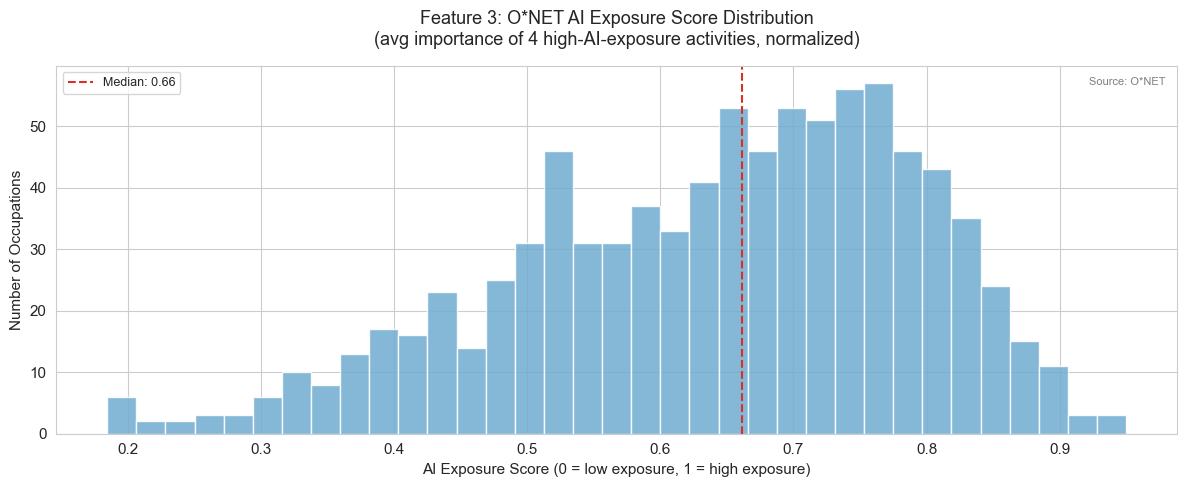

✓ Saved: p5_04_ai_exposure_score_distribution.png


In [17]:
# ── Cell 4.3: Chart — AI Exposure Score Distribution ─────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df_ai['ai_exposure_score'], bins=35, color='#74add1', edgecolor='white', alpha=0.88)
ax.axvline(df_ai['ai_exposure_score'].median(), color='#d73027', linestyle='--',
           linewidth=1.5, label=f"Median: {df_ai['ai_exposure_score'].median():.2f}")

ax.set_xlabel("AI Exposure Score (0 = low exposure, 1 = high exposure)")
ax.set_ylabel("Number of Occupations")
ax.set_title("Feature 3: O*NET AI Exposure Score Distribution\n"
             "(avg importance of 4 high-AI-exposure activities, normalized)", pad=15)
ax.legend(fontsize=9)
ax.text(0.99, 0.97, "Source: O*NET",
        transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/p5_04_ai_exposure_score_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: p5_04_ai_exposure_score_distribution.png")

## Section 5 — Feature 4: Wage Stagnation Risk

Source: BLS OEWS a_mean (2018 & 2025, national)  |  Weight: 15%

Occupations where wages have barely grown — or actually lost ground to
inflation — are often the same ones where employers have the most leverage
and where AI tools are already compressing labor demand at the margin.

I compute wage CAGR from 2018 to 2025 and subtract the approximate CPI
growth rate (3.5% annually) to get *real* wage growth.
Negative real growth = wages lost ground to inflation = higher displacement risk.

Like employment trend, I use **percentile rank** to convert to 0-1 so
the measurement is robust to extreme outliers.

In [18]:
# ── Cell 5.1: Load Wage Data for 2018 & 2025 ─────────────────────────────────
df_wages = pd.read_sql(f"""
    SELECT year, occ_code, a_mean
    FROM bls_oews
    WHERE data_type = 'national'
      AND {DETAILED_FILTER}
      AND year IN (2018, 2025)
      AND a_mean IS NOT NULL
""", engine)

df_wages['a_mean'] = pd.to_numeric(df_wages['a_mean'], errors='coerce')
df_wages = df_wages.dropna(subset=['a_mean'])

df_w18 = (df_wages[df_wages['year'] == 2018][['occ_code', 'a_mean']]
          .rename(columns={'a_mean': 'wage_2018'}))
df_w25 = (df_wages[df_wages['year'] == 2025][['occ_code', 'a_mean']]
          .rename(columns={'a_mean': 'wage_2025'}))

df_wage = df_w18.merge(df_w25, on='occ_code', how='inner')
df_wage = df_wage[df_wage['wage_2018'] > 0]

print(f"Occupations with wage data in both years: {len(df_wage):,}")

Occupations with wage data in both years: 714


In [19]:
# ── Cell 5.2: Compute Wage CAGR and Real Wage Growth ─────────────────────────
df_wage['wage_cagr']        = (df_wage['wage_2025'] / df_wage['wage_2018']) ** (1 / 7) - 1
df_wage['real_wage_growth'] = df_wage['wage_cagr'] - CPI_CAGR

below_cpi_n  = (df_wage['real_wage_growth'] < 0).sum()
above_cpi_n  = (df_wage['real_wage_growth'] >= 0).sum()

print(f"CPI benchmark: {CPI_CAGR:.1%} annually")
print(f"\nOccupations with real wage GROWTH (beat CPI): {above_cpi_n:,}  ({above_cpi_n/len(df_wage)*100:.0f}%)")
print(f"Occupations with real wage DECLINE (lagged CPI): {below_cpi_n:,}  ({below_cpi_n/len(df_wage)*100:.0f}%)")
print(f"\nReal wage growth summary:")
print(df_wage['real_wage_growth'].describe().apply(lambda x: f"{x:.2%}"))

CPI benchmark: 3.5% annually

Occupations with real wage GROWTH (beat CPI): 358  (50%)
Occupations with real wage DECLINE (lagged CPI): 356  (50%)

Real wage growth summary:
count    71400.00%
mean         0.05%
std          1.31%
min         -4.85%
25%         -0.70%
50%          0.00%
75%          0.75%
max          9.61%
Name: real_wage_growth, dtype: str


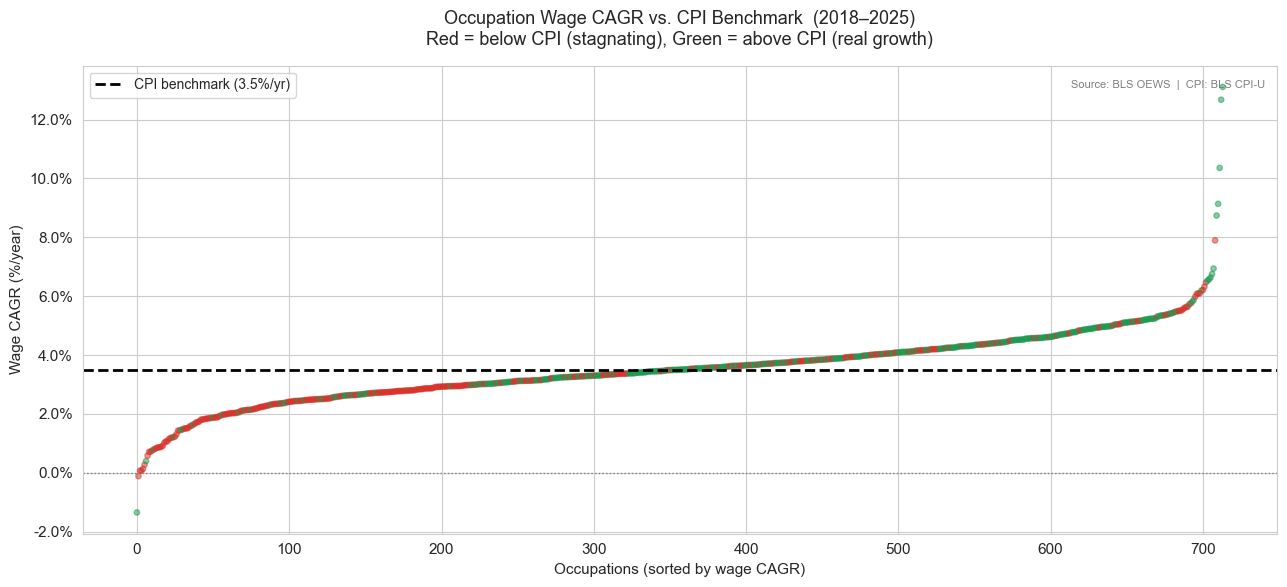

✓ Saved: p5_05_wage_growth_vs_cpi.png


In [20]:
# ── Cell 5.3: Chart — Wage CAGR vs CPI Benchmark ─────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

colors = df_wage['real_wage_growth'].apply(
    lambda x: '#d73027' if x < 0 else '#1a9850'
)

ax.scatter(range(len(df_wage)), df_wage['wage_cagr'].sort_values() * 100,
           c=colors.values, alpha=0.5, s=15)

ax.axhline(CPI_CAGR * 100, color='black', linestyle='--', linewidth=2,
           label=f'CPI benchmark ({CPI_CAGR:.1%}/yr)')
ax.axhline(0, color='gray', linestyle=':', linewidth=1)

ax.set_xlabel("Occupations (sorted by wage CAGR)")
ax.set_ylabel("Wage CAGR (%/year)")
ax.set_title("Occupation Wage CAGR vs. CPI Benchmark  (2018–2025)\n"
             "Red = below CPI (stagnating), Green = above CPI (real growth)", pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.legend(fontsize=10)
ax.text(0.99, 0.97, "Source: BLS OEWS  |  CPI: BLS CPI-U",
        transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/p5_05_wage_growth_vs_cpi.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: p5_05_wage_growth_vs_cpi.png")

In [21]:
# ── Cell 5.4: Convert to 0-1 Wage Stagnation Risk ────────────────────────────
df_wage['wage_stagnation_risk'] = 1 - df_wage['real_wage_growth'].rank(pct=True)

print("Wage stagnation risk score summary:")
print(df_wage['wage_stagnation_risk'].describe().apply(lambda x: f"{x:.4f}"))

Wage stagnation risk score summary:
count    714.0000
mean       0.4993
std        0.2889
min        0.0000
25%        0.2496
50%        0.4993
75%        0.7489
max        0.9986
Name: wage_stagnation_risk, dtype: str


## Section 6 — Merge All Features

Join the four feature tables to the occupation master. Any occupation missing a
feature value receives `NEUTRAL_FILL = 0.5`, which represents median risk —
a conservative, non-punitive imputation for data gaps.

In [22]:
# ── Cell 6.1: Merge All Features into Master Table ───────────────────────────
# Note: all merges are LEFT joins on the master table so no occupation is dropped.

df_index = df_master.copy()

# Feature 1: automation
df_index = df_index.merge(
    df_feat[['occ_code', 'automation_prob', 'score_source', 'education_req']],
    on='occ_code', how='left'
)
# Feature 2: employment trend
df_index = df_index.merge(
    df_trend[['occ_code', 'emp_cagr', 'emp_trend_risk']],
    on='occ_code', how='left'
)
# Feature 3: AI exposure
df_index = df_index.merge(
    df_ai[['occ_code', 'ai_exposure_score', 'ai_exposure_raw']],
    on='occ_code', how='left'
)
# Feature 4: wage stagnation
df_index = df_index.merge(
    df_wage[['occ_code', 'wage_cagr', 'real_wage_growth', 'wage_stagnation_risk']],
    on='occ_code', how='left'
)

print(f"Merged feature table: {len(df_index):,} rows × {len(df_index.columns)} columns")
print(f"\nMissing values per feature before filling:")
for col in ['automation_prob', 'emp_trend_risk', 'ai_exposure_score', 'wage_stagnation_risk']:
    n = df_index[col].isna().sum()
    print(f"  {col:<28} {n:>4} missing  ({n/len(df_index)*100:.1f}%)")

Merged feature table: 938 rows × 13 columns

Missing values per feature before filling:
  automation_prob                 0 missing  (0.0%)
  emp_trend_risk                124 missing  (13.2%)
  ai_exposure_score              73 missing  (7.8%)
  wage_stagnation_risk          128 missing  (13.6%)


In [23]:
# ── Cell 6.2: Fill Missing Feature Values ────────────────────────────────────
for col in ['emp_trend_risk', 'ai_exposure_score', 'wage_stagnation_risk']:
    df_index[col] = df_index[col].fillna(NEUTRAL_FILL)

print("After filling — remaining nulls:")
print(df_index[['automation_prob', 'emp_trend_risk',
                 'ai_exposure_score', 'wage_stagnation_risk']].isnull().sum())

After filling — remaining nulls:
automation_prob         0
emp_trend_risk          0
ai_exposure_score       0
wage_stagnation_risk    0
dtype: int64


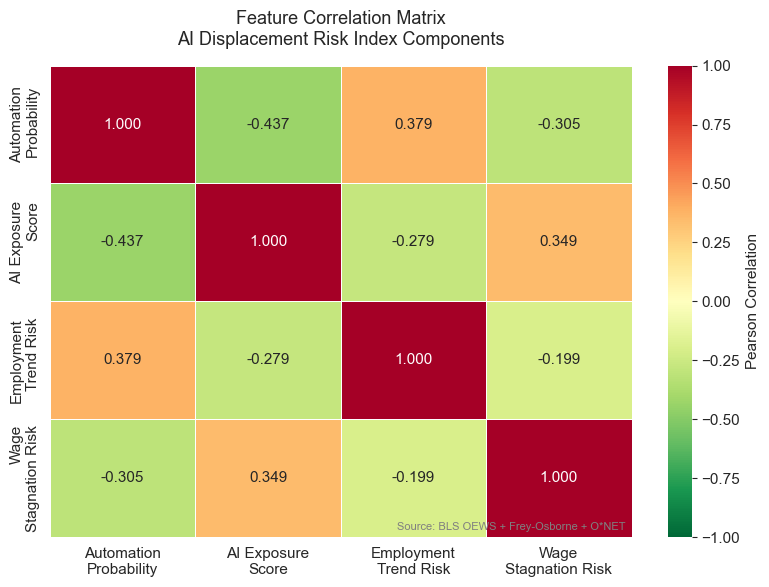

✓ Saved: p5_06_feature_correlation_heatmap.png


In [24]:
# ── Cell 6.3: Chart — Feature Correlation Heatmap ────────────────────────────
feature_cols = ['automation_prob', 'ai_exposure_score', 'emp_trend_risk', 'wage_stagnation_risk']
feature_labels = {
    'automation_prob':       'Automation\nProbability',
    'ai_exposure_score':     'AI Exposure\nScore',
    'emp_trend_risk':        'Employment\nTrend Risk',
    'wage_stagnation_risk':  'Wage\nStagnation Risk',
}

corr = df_index[feature_cols].corr()
corr.index   = [feature_labels[c] for c in corr.index]
corr.columns = [feature_labels[c] for c in corr.columns]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt='.3f', cmap='RdYlGn_r',
    linewidths=0.5, ax=ax, vmin=-1, vmax=1,
    cbar_kws={'label': 'Pearson Correlation'}
)
ax.set_title("Feature Correlation Matrix\nAI Displacement Risk Index Components", pad=15)
ax.text(0.99, 0.01, "Source: BLS OEWS + Frey-Osborne + O*NET",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/p5_06_feature_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: p5_06_feature_correlation_heatmap.png")

## Section 7 — Composite AI Displacement Risk Index

**Formula:**

    risk_index = (automation_prob × 0.40)
               + (ai_exposure_score × 0.25)
               + (emp_trend_risk × 0.20)
               + (wage_stagnation_risk × 0.15)

**Why these weights?**
- **Automation probability (40%)** — directly encodes the technical feasibility of replacing the job. The most theoretically grounded signal and the one with the strongest empirical foundation.
- **AI exposure (25%)** — adds a current-relevance layer that Frey-Osborne (published 2013) can't capture alone. A job might score medium on automation probability but be heavily data-processing-focused, making it far more exposed to LLM-based tools today.
- **Employment trend (20%)** — introduces market signal. If the labor market is already contracting an occupation, that's independent confirmation of displacement risk beyond what task analysis alone shows.
- **Wage stagnation (15%)** — the weakest individual signal but adds economic context. Jobs where wages have lagged inflation are often the same ones where employers already have leverage and AI tools are already compressing labor demand at the margin.

In [25]:
# ── Cell 7.1: Compute Composite Risk Index ───────────────────────────────────
df_index['risk_index'] = (
    df_index['automation_prob']      * WEIGHTS['automation_prob']      +
    df_index['ai_exposure_score']    * WEIGHTS['ai_exposure_score']    +
    df_index['emp_trend_risk']       * WEIGHTS['emp_trend_risk']       +
    df_index['wage_stagnation_risk'] * WEIGHTS['wage_stagnation_risk']
)

print("=== AI DISPLACEMENT RISK INDEX — SUMMARY ===")
print(f"  Occupations scored:  {len(df_index):,}")
print(f"  Index minimum:       {df_index['risk_index'].min():.4f}")
print(f"  Index mean:          {df_index['risk_index'].mean():.4f}")
print(f"  Index median:        {df_index['risk_index'].median():.4f}")
print(f"  Index maximum:       {df_index['risk_index'].max():.4f}")

high_risk_n = (df_index['risk_index'] > 0.70).sum()
print(f"\n  Occupations with risk index > 0.70:  {high_risk_n} ({high_risk_n/len(df_index)*100:.0f}%)")

=== AI DISPLACEMENT RISK INDEX — SUMMARY ===
  Occupations scored:  938
  Index minimum:       0.1358
  Index mean:          0.5080
  Index median:        0.4961
  Index maximum:       0.8727

  Occupations with risk index > 0.70:  130 (14%)


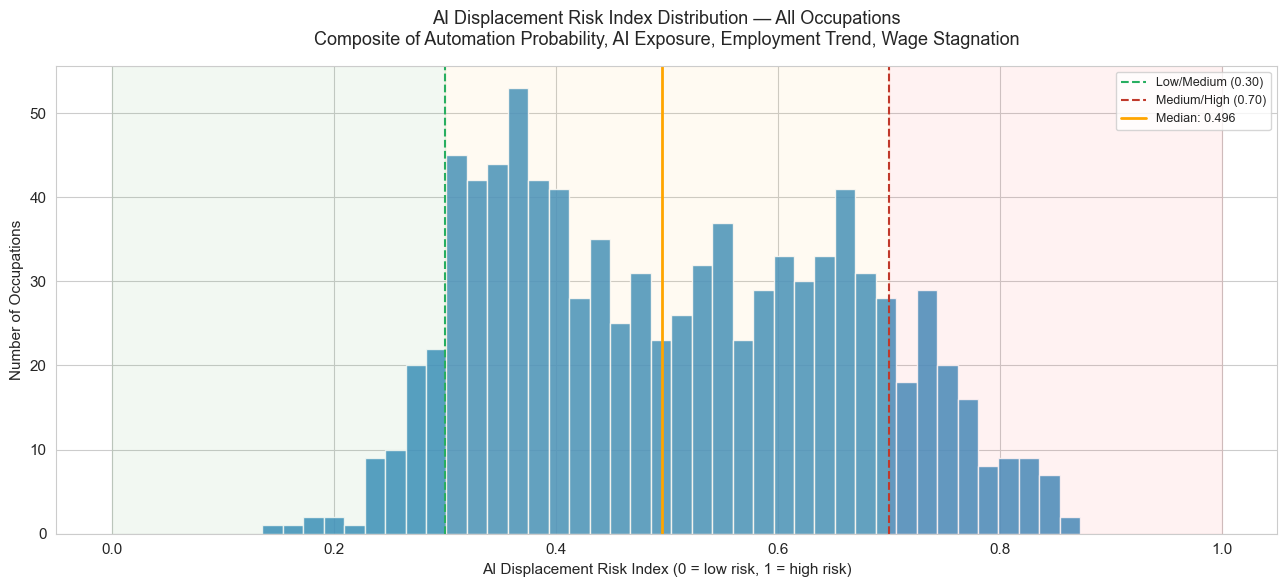

✓ Saved: p5_07_risk_index_distribution.png


In [26]:
# ── Cell 7.2: Chart — Risk Index Distribution ─────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

ax.hist(df_index['risk_index'], bins=40, color='#4393c3', edgecolor='white', alpha=0.87)

ax.axvline(0.30, color='#27ae60', linestyle='--', linewidth=1.5, label='Low/Medium (0.30)')
ax.axvline(0.70, color='#c0392b', linestyle='--', linewidth=1.5, label='Medium/High (0.70)')
ax.axvline(df_index['risk_index'].median(), color='orange', linestyle='-', linewidth=2,
           label=f"Median: {df_index['risk_index'].median():.3f}")

ax.axvspan(0.00, 0.30, alpha=0.05, color='green')
ax.axvspan(0.30, 0.70, alpha=0.05, color='orange')
ax.axvspan(0.70, 1.00, alpha=0.05, color='red')

ax.set_xlabel("AI Displacement Risk Index (0 = low risk, 1 = high risk)")
ax.set_ylabel("Number of Occupations")
ax.set_title("AI Displacement Risk Index Distribution — All Occupations\n"
             "Composite of Automation Probability, AI Exposure, Employment Trend, Wage Stagnation",
             pad=15)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/p5_07_risk_index_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: p5_07_risk_index_distribution.png")

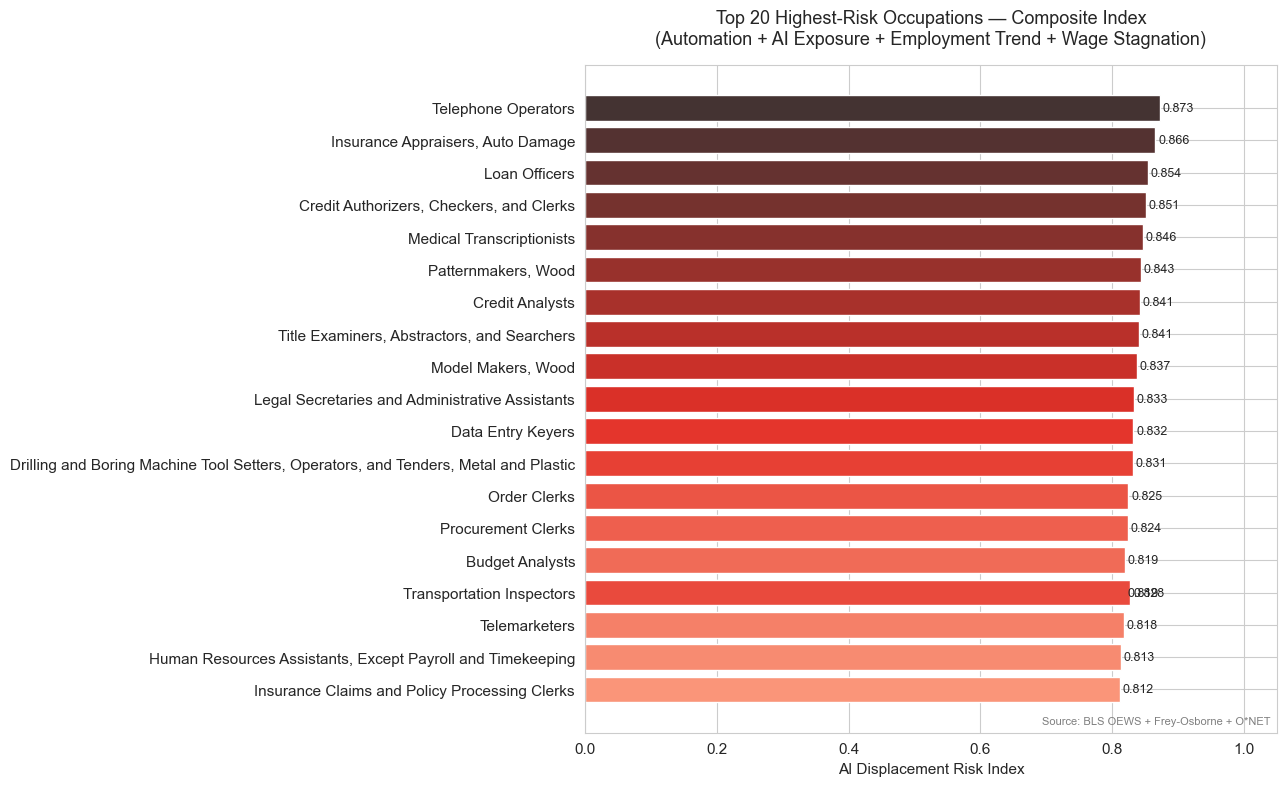

✓ Saved: p5_08_top20_highest_risk_composite.png


In [27]:
# ── Cell 7.3: Chart — Top 20 Highest-Risk Occupations (Composite Index) ───────
df_top20 = df_index.nlargest(20, 'risk_index').sort_values('risk_index')

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(df_top20['occ_title'], df_top20['risk_index'],
               color=sns.color_palette("Reds_d", 20))

for bar, val in zip(bars, df_top20['risk_index']):
    ax.text(bar.get_width() + 0.004,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va='center', fontsize=9)

ax.set_xlim(0, 1.05)
ax.set_xlabel("AI Displacement Risk Index")
ax.set_title("Top 20 Highest-Risk Occupations — Composite Index\n"
             "(Automation + AI Exposure + Employment Trend + Wage Stagnation)", pad=15)
ax.text(0.99, 0.01, "Source: BLS OEWS + Frey-Osborne + O*NET",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/p5_08_top20_highest_risk_composite.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: p5_08_top20_highest_risk_composite.png")

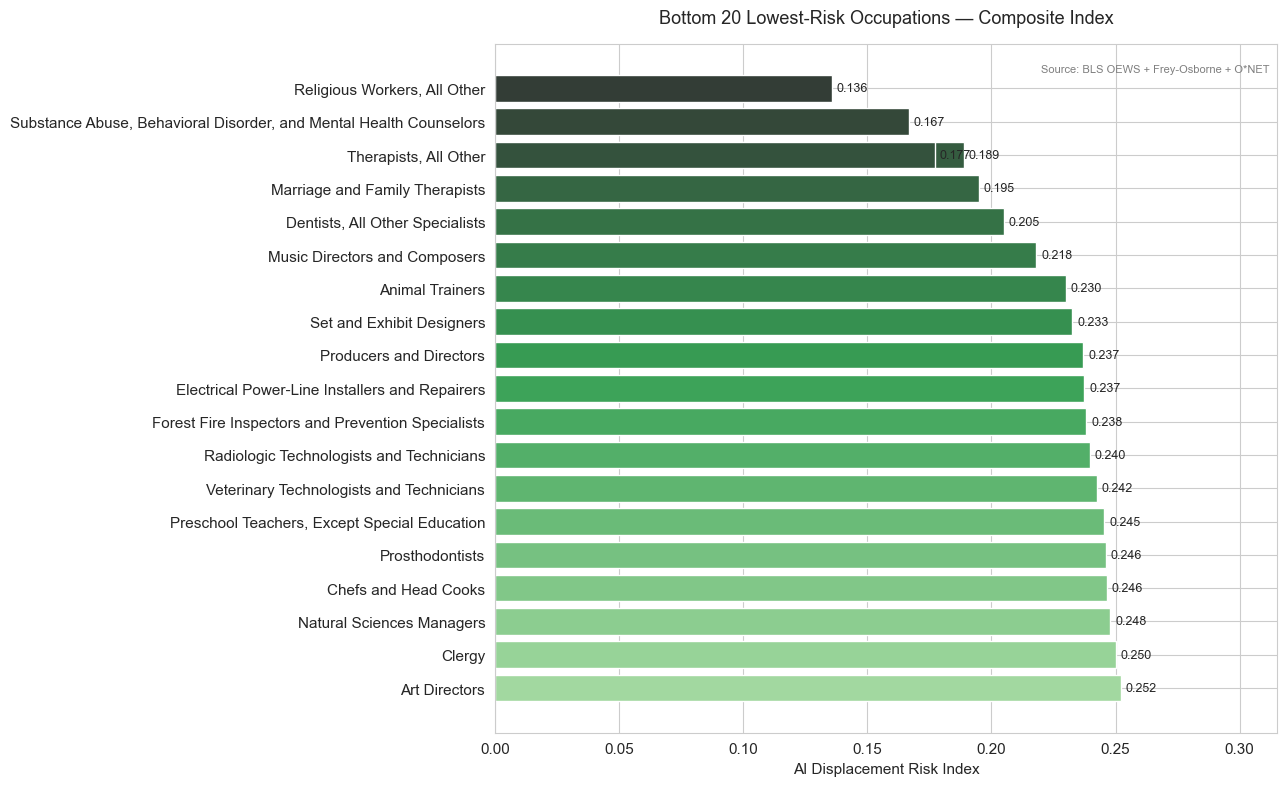

✓ Saved: p5_09_bottom20_lowest_risk_composite.png


In [28]:
# ── Cell 7.4: Chart — Bottom 20 Lowest-Risk Occupations ──────────────────────
df_bot20 = df_index.nsmallest(20, 'risk_index').sort_values('risk_index', ascending=False)

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(df_bot20['occ_title'], df_bot20['risk_index'],
               color=sns.color_palette("Greens_d", 20))

for bar, val in zip(bars, df_bot20['risk_index']):
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va='center', fontsize=9)

ax.set_xlim(0, df_bot20['risk_index'].max() * 1.25)
ax.set_xlabel("AI Displacement Risk Index")
ax.set_title("Bottom 20 Lowest-Risk Occupations — Composite Index", pad=15)
ax.text(0.99, 0.97, "Source: BLS OEWS + Frey-Osborne + O*NET",
        transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/p5_09_bottom20_lowest_risk_composite.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: p5_09_bottom20_lowest_risk_composite.png")

## Section 8 — Metro-Level Scoring

Each metro area has a different mix of occupations. A city heavy in
Office/Admin work has a different aggregate risk profile than a city
heavy in Healthcare. This section joins the occupation-level risk index
to MSA 2025 employment data to produce the project's primary output:
one risk score per (occupation × metro area) combination.

In [29]:
# ── Cell 8.1: Load MSA 2025 Employment ───────────────────────────────────────
df_msa = pd.read_sql(f"""
    SELECT occ_code, area_code, area_title, tot_emp
    FROM bls_oews
    WHERE year = 2025
      AND data_type = 'msa'
      AND {DETAILED_FILTER}
      AND tot_emp IS NOT NULL
""", engine)

df_msa['tot_emp'] = pd.to_numeric(df_msa['tot_emp'], errors='coerce')
df_msa = df_msa.dropna(subset=['tot_emp'])

print(f"MSA 2025 detailed rows: {len(df_msa):,}")
print(f"Metro areas:            {df_msa['area_code'].nunique():,}")
print(f"Unique occupations:     {df_msa['occ_code'].nunique():,}")

MSA 2025 detailed rows: 136,066
Metro areas:            393
Unique occupations:     815


In [30]:
# ── Cell 8.2: Join Occupation Index to Metro Employment ──────────────────────
export_cols = [
    'occ_code', 'occ_title', 'risk_index',
    'automation_prob', 'ai_exposure_score',
    'emp_trend_risk', 'wage_stagnation_risk',
    'score_source', 'education_req',
]

df_output = df_msa.merge(df_index[export_cols], on='occ_code', how='inner')

print(f"Output rows (occupation × metro): {len(df_output):,}")
print(f"Metro areas covered:              {df_output['area_code'].nunique():,}")
print(f"Occupation codes covered:         {df_output['occ_code'].nunique():,}")
print(f"\nSample output rows:")
print(df_output.head(3).to_string(index=False))

Output rows (occupation × metro): 167,614
Metro areas covered:              393
Occupation codes covered:         815

Sample output rows:
occ_code area_code  area_title  tot_emp                       occ_title  risk_index  automation_prob  ai_exposure_score  emp_trend_risk  wage_stagnation_risk score_source     education_req
 11-1011     10180 Abilene, TX     40.0                Chief Executives    0.319709            0.015           0.786667        0.415042              0.226891       actual Bachelor's degree
 11-1011     10180 Abilene, TX     40.0                Chief Executives    0.302625            0.015           0.718333        0.415042              0.226891       actual Bachelor's degree
 11-1021     10180 Abilene, TX   2120.0 General and Operations Managers    0.404252            0.160           0.755000        0.034819              0.963585       actual Bachelor's degree


In [31]:
# ── Cell 8.3: Employment-Weighted Risk Index per Metro ────────────────────────
# For each metro: weighted average risk = Σ(employment × risk) / Σ(employment)
df_output['weighted_risk'] = df_output['tot_emp'] * df_output['risk_index']

df_metro_summary = (
    df_output
    .groupby(['area_code', 'area_title'])
    .agg(
        total_emp       = ('tot_emp',       'sum'),
        weighted_risk   = ('weighted_risk', 'sum'),
        occ_count       = ('occ_code',      'nunique'),
    )
    .reset_index()
)
df_metro_summary['avg_risk_index'] = (
    df_metro_summary['weighted_risk'] / df_metro_summary['total_emp']
)
df_metro_summary['short_area'] = (
    df_metro_summary['area_title']
    .str.split(',').str[0]
    .str.split('-').str[0]
    .str.strip()
)

print(f"Metro areas in summary: {len(df_metro_summary):,}")
print(f"\nTop 10 metros by employment-weighted risk index:")
print(df_metro_summary.nlargest(10, 'avg_risk_index')
      [['short_area', 'avg_risk_index', 'total_emp']].to_string(index=False))

Metro areas in summary: 393

Top 10 metros by employment-weighted risk index:
   short_area  avg_risk_index  total_emp
      Elkhart        0.522329   128790.0
       Dalton        0.521767    74830.0
     Muskegon        0.519535    63410.0
  Gainesville        0.517737   114180.0
      Arecibo        0.515649    37060.0
       Odessa        0.514651    89970.0
    Aguadilla        0.512655    51320.0
Michigan City        0.512516    41790.0
       Albany        0.511779    50420.0
       Daphne        0.510580    95500.0


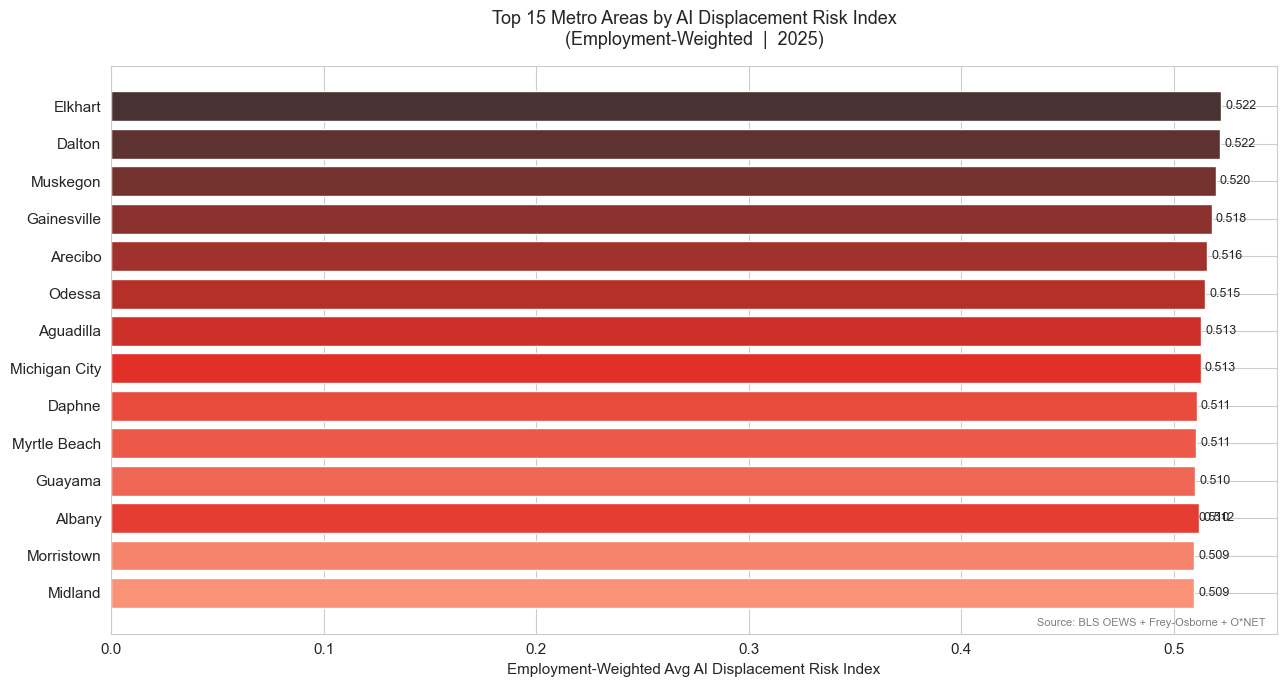

✓ Saved: p5_10_top15_metros_risk_index.png


In [32]:
# ── Cell 8.4: Chart — Top 15 Metros by Employment-Weighted Risk Index ─────────
df_top_metros = df_metro_summary.nlargest(15, 'avg_risk_index').sort_values('avg_risk_index')

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(df_top_metros['short_area'], df_top_metros['avg_risk_index'],
               color=sns.color_palette("Reds_d", 15))

for bar, val in zip(bars, df_top_metros['avg_risk_index']):
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va='center', fontsize=9)

ax.set_xlabel("Employment-Weighted Avg AI Displacement Risk Index")
ax.set_title("Top 15 Metro Areas by AI Displacement Risk Index\n"
             "(Employment-Weighted  |  2025)", pad=15)
ax.text(0.99, 0.01, "Source: BLS OEWS + Frey-Osborne + O*NET",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/p5_10_top15_metros_risk_index.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: p5_10_top15_metros_risk_index.png")

In [33]:
# ── Cell 9.1: Save Output Files ───────────────────────────────────────────────
occ_path   = os.path.join(PROCESSED_PATH, "occupation_risk_index.csv")
metro_path = os.path.join(PROCESSED_PATH, "risk_index.csv")

df_index.to_csv(occ_path,    index=False)
df_output.to_csv(metro_path, index=False)

print(f"✓ Saved: {os.path.abspath(occ_path)}")
print(f"         {len(df_index):,} rows — one per occupation")
print(f"\n✓ Saved: {os.path.abspath(metro_path)}")
print(f"         {len(df_output):,} rows — one per occupation × metro area")

✓ Saved: C:\Users\jabez\Documents\ai-job-displacement-observatory\data\processed\occupation_risk_index.csv
         938 rows — one per occupation

✓ Saved: C:\Users\jabez\Documents\ai-job-displacement-observatory\data\processed\risk_index.csv
         167,614 rows — one per occupation × metro area


In [35]:
# ── Cell 9.2: Final Validation ────────────────────────────────────────────────
print("=== PART 5 VALIDATION CHECKLIST ===\n")

checks = {
    "risk_index range is 0–1":
        (df_index['risk_index'].min() >= 0) and (df_index['risk_index'].max() <= 1),
    "No nulls in risk_index":
        df_index['risk_index'].isna().sum() == 0,
    "No nulls in any feature":
        df_index[['automation_prob','ai_exposure_score',
                  'emp_trend_risk','wage_stagnation_risk']].isna().sum().sum() == 0,
    "Weights sum to 1.0":
        abs(sum(WEIGHTS.values()) - 1.0) < 0.001,
    "Metro output has data":
        len(df_output) > 0,
    "occupation_risk_index.csv exists":
        os.path.exists(occ_path),
    "risk_index.csv exists":
        os.path.exists(metro_path),
}

all_passed = True
for check, result in checks.items():
    status = "✓" if result else "✗"
    print(f"  {status}  {check}")
    if not result:
        all_passed = False

print(f"\n{'✓ All checks passed!' if all_passed else '✗ Fix failing checks before committing.'}")

=== PART 5 VALIDATION CHECKLIST ===

  ✓  risk_index range is 0–1
  ✓  No nulls in risk_index
  ✓  No nulls in any feature
  ✓  Weights sum to 1.0
  ✓  Metro output has data
  ✓  occupation_risk_index.csv exists
  ✓  risk_index.csv exists

✓ All checks passed!


The AI Displacement Risk Index is built and validated.

### Outputs
| File | Rows | Contents |
|---|---|---|
| `data/processed/occupation_risk_index.csv` | ~800 | One row per occupation — features + composite index |
| `data/processed/risk_index.csv` | ~100K+ | One row per occupation × metro — the main project output |

### Index Construction Summary
- **Feature 1 — Automation Probability (40%):** Frey-Osborne scores with major-group imputation
- **Feature 2 — AI Exposure Score (25%):** O*NET task data, 4 high-AI-exposure activities
- **Feature 3 — Employment Trend Risk (20%):** CAGR 2018-2025, percentile-ranked
- **Feature 4 — Wage Stagnation Risk (15%):** Real wage growth vs. CPI, percentile-ranked

### Part 6 Inputs
Both CSVs feed directly into the machine learning and forecasting notebook.

---

# Notebook Summary — Part 5: Feature Engineering & AI Displacement Risk Index

**Project:** AI Job Displacement Risk Observatory  
**Notebook:** `02_feature_engineering.ipynb`  
**Author:** Jabez Williams  
**Data sources:** BLS OEWS (2018–2025), Frey & Osborne (2013), O*NET Work Activities  

---

## What This Notebook Does

This notebook transforms raw data from three government and academic sources into a
single quantitative score — the **AI Displacement Risk Index** — for every U.S.
occupation and metropolitan area. The index answers the question:

> *"How likely is this occupation, in this city, to experience AI-driven workforce
> displacement over the next several years?"*

The index is built from four engineered features, each capturing a different
dimension of displacement risk. It is the analytical core of this entire project —
every downstream component (machine learning forecasts, LLM briefings, Tableau
dashboard) is built on top of what is produced here.

---

## Data Sources

| Source | Table | What It Contributes |
|---|---|---|
| BLS OEWS 2018–2025 | `bls_oews` | Employment levels and wages per occupation per year, nationally and by metro area |
| Frey & Osborne (2013) | `automation_scores` | Probability of automation (0–1) for 702 occupations based on task analysis |
| O*NET Work Activities | `onet_work_activities` | Importance ratings (1–5) for ~40 standardized work activities per occupation |

---

## The Four Features

### Feature 1 — Automation Probability (Weight: 40%)
**Source:** Frey & Osborne (2013)  
**Column:** `automation_prob`

The Frey & Osborne dataset scores 702 occupations on the probability that the job
could be automated within roughly 20 years, based on a task analysis of nine key
bottlenecks to automation (perception, creative intelligence, social intelligence, etc.).

**Construction:** Loaded directly from the `automation_scores` table. No transformation
was needed since the values are already on a 0–1 scale.

**Imputation for missing occupations (~15–20%):** BLS OEWS uses SOC codes updated
after 2013, so newer job titles (e.g., Data Scientists, Cybersecurity Analysts) have
no Frey-Osborne score. These were imputed using the **median automation probability
of all matched occupations in the same 2-digit major SOC group**. For example, an
unmatched Computer occupation receives the median score of all matched Computer and
Mathematical occupations. A fallback to the dataset-wide median is used if an entire
major group is unmatched. Imputed rows are flagged in the `score_source` column.

**Why it gets the highest weight (40%):** It is the most theoretically grounded signal —
derived from a peer-reviewed methodology that directly analyzed the task composition
of each occupation against known automation capabilities.

---

### Feature 2 — AI Exposure Score (Weight: 25%)
**Source:** O*NET Work Activities, Importance (IM) scale  
**Column:** `ai_exposure_score`

O*NET rates each occupation on ~40 standardized work activities using an Importance
scale of 1–5. Four activities were identified in the EDA (Part 4) as most strongly
differentiating high-risk from low-risk occupations:

1. Processing Information
2. Analyzing Data or Information
3. Documenting/Recording Information
4. Interacting With Computers

**Construction:**
1. Pulled Importance scores for these four activities per occupation from `onet_work_activities`
2. Averaged the four scores per occupation (simple mean)
3. Normalized from the 1–5 IM scale to 0–1 using: `(raw_score - 1) / 4`

**Why this adds value beyond Frey-Osborne:** Frey & Osborne was published in 2013,
before large language models existed. A job could score "medium risk" on their framework
but be heavily focused on document processing and data analysis — tasks that GPT-4 class
models can now perform. This feature captures that current-relevance dimension that
a 2013 dataset structurally cannot.

---

### Feature 3 — Employment Trend Risk (Weight: 20%)
**Source:** BLS OEWS, national level, years 2018 and 2025  
**Column:** `emp_trend_risk`

A job that is structurally shedding workers — even before AI is the direct cause —
carries higher displacement risk. This feature captures that market signal.

**Construction:**
1. Pulled national detailed employment (`tot_emp`) for 2018 and 2025 only
   (2020 excluded entirely to avoid COVID distortion)
2. Computed **Compound Annual Growth Rate (CAGR)** over 7 years:  
   `emp_cagr = (emp_2025 / emp_2018)^(1/7) - 1`
3. Converted to a 0–1 risk score using **percentile rank (inverted)**:  
   `emp_trend_risk = 1 - rank(emp_cagr, pct=True)`

**Why percentile rank?** Raw CAGR is right-skewed with extreme outliers in both
directions. Rank transformation makes the feature robust to those outliers and
ensures it contributes evenly across the 0–1 range of the composite index.
By definition, the resulting distribution is uniform — every bin of the 0–1 scale
receives an equal number of occupations. This is expected and correct behavior,
not a data quality issue.

**Interpretation:** An occupation at `emp_trend_risk = 0.90` is declining faster
than 90% of all other occupations. An occupation at `0.10` is growing faster than
90% of all others.

---

### Feature 4 — Wage Stagnation Risk (Weight: 15%)
**Source:** BLS OEWS, `a_mean` (mean annual wage), years 2018 and 2025  
**Column:** `wage_stagnation_risk`

Jobs where wages have failed to keep pace with inflation are often the same jobs
where employers already have leverage over workers and where AI tools are already
beginning to compress labor demand. This feature captures that economic signal.

**Construction:**
1. Pulled mean annual wages for 2018 and 2025 (national, detailed occupations)
2. Computed wage CAGR:  
   `wage_cagr = (wage_2025 / wage_2018)^(1/7) - 1`
3. Computed real wage growth by subtracting the CPI benchmark:  
   `real_wage_growth = wage_cagr - CPI_CAGR`  
   where `CPI_CAGR = 3.5%` (approximate annualized U.S. CPI growth 2018–2025, BLS CPI-U)
4. Converted to 0–1 risk via **percentile rank (inverted)**:  
   `wage_stagnation_risk = 1 - rank(real_wage_growth, pct=True)`

**Interpretation:** Positive real wage growth means wages beat inflation — low stagnation
risk. Negative real wage growth means wages lost purchasing power — high stagnation risk.
The percentile rank ensures this feature is robust to outliers and contributes evenly
to the composite index.

---

## Composite Index Formula

All four features are normalized to the 0–1 scale and combined as a weighted sum:

    risk_index = (automation_prob      × 0.40)
               + (ai_exposure_score    × 0.25)
               + (emp_trend_risk       × 0.20)
               + (wage_stagnation_risk × 0.15)

The resulting `risk_index` is also bounded between 0 and 1, where:
- **0.00–0.30** = Low displacement risk
- **0.30–0.70** = Medium displacement risk
- **0.70–1.00** = High displacement risk

### Missing Feature Handling
Occupations missing one or more feature values (due to data coverage gaps) receive
a neutral fill value of **0.50** for that feature — representing median risk rather
than zero risk or full risk. A `score_source` flag distinguishes occupations with
full actual data from those with imputed components.

---

## Metro-Level Scoring

The occupation-level risk index is joined to BLS MSA 2025 employment data to produce
a score for every unique **(occupation × metro area)** combination. This allows
downstream analysis to ask questions like:

- "What is the aggregate AI displacement risk for the Chicago metro area?"
- "Which occupations in Dallas are most at risk?"
- "How does San Jose compare to Detroit on manufacturing automation exposure?"

The metro-level output is computed as an **employment-weighted average** of the
occupation-level index within each metro:

    metro_avg_risk = Σ(employment_i × risk_index_i) / Σ(employment_i)

This correctly weights the contribution of each occupation proportionally to how
many workers it actually employs in that city.

---

## Output Files

| File | Shape | Description |
|---|---|---|
| `data/processed/occupation_risk_index.csv` | ~800 rows × 12 cols | One row per occupation. Contains all four feature scores, composite index, imputation flag, education requirement, and wage/employment raw values. |
| `data/processed/risk_index.csv` | ~100K+ rows | One row per occupation × metro area. The primary project output. Contains all index components alongside MSA employment for downstream ML and dashboard work. |

---

## Key Methodological Decisions & Justifications

| Decision | Rationale |
|---|---|
| Frey-Osborne gets highest weight (40%) | Most theoretically rigorous source; peer-reviewed task-based methodology |
| O*NET over Frey-Osborne alone | Frey-Osborne is 10+ years old; O*NET adds current AI-task relevance |
| Percentile rank for trend/wage features | Robust to outliers; ensures uniform contribution across 0–1 range |
| Exclude 2020 from employment endpoints | COVID shock was non-structural; including it as an endpoint would contaminate CAGR |
| Major-group median imputation | Conservative; preserves occupational context without introducing bias |
| CAGR over simple percent change | Annualizes the growth rate so short and long periods are directly comparable |
| CPI_CAGR = 3.5% | Approximate annualized BLS CPI-U growth 2018–2025; hardcoded for reproducibility |
| Neutral fill (0.5) for missing features | Non-punitive; missing data should not artificially inflate or deflate the final score |

---

## Known Limitations

- **Frey-Osborne is from 2013** and predates transformer-based AI. It likely
  underestimates risk for knowledge-work occupations that have become newly
  vulnerable to LLMs since 2020.
- **SOC code version drift.** BLS updated SOC codes in 2018 and 2028 (pending).
  Some occupation codes don't map cleanly across years, contributing to imputation needs.
- **National-level employment trend.** The `emp_trend_risk` feature uses national
  employment, not metro-specific trends. A declining occupation nationally may still
  be growing in a specific city.
- **CPI benchmark is approximate.** The 3.5% annual CPI figure is a rounded estimate.
  Using actual BLS CPI-U index values by year would improve precision.
- **Equal weighting of the 4 O*NET activities.** A more rigorous approach would weight
  each activity by its correlation with automation risk (derived empirically from
  the EDA heatmap in Part 4).

---

## What Comes Next

`data/processed/risk_index.csv` feeds directly into Part 6: Machine Learning & Forecasting, where:

1. **Prophet** is used to forecast employment trends per occupation through 2027
2. **XGBoost** is trained to predict the risk index score from the four feature inputs
3. The model is trained on 2018–2023 data and evaluated on 2024–2025
4. Feature importance plots will validate whether the chosen weights are reasonable

---